# 02 - Elo Ratings

Stage 2 builds the team-strength layer: chronological Elo ratings with tournament-tier weighting, non-neutral home advantage, margin-of-victory scaling, and annual regression toward the mean. No Poisson, optimizer, or bracket logic is used here.

## Setup

Load the cleaned historical results and compute the rating history. Team names are canonicalized inside `compute_elo_ratings()` so ratings attach to the same spellings used by the historical dataset.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import src.elo as elo_mod
from src.data_loader import clean_results, fetch_international_results
from src.elo import compute_elo_ratings, get_ratings_asof

sns.set_theme(style="whitegrid")

In [2]:
raw_results = fetch_international_results(force_refresh=False)
results = clean_results(raw_results)
ratings, history = compute_elo_ratings(results)

ratings_df = (
    pd.DataFrame(ratings.items(), columns=["team", "rating"])
    .sort_values("rating", ascending=False)
    .reset_index(drop=True)
)

print(f"Clean matches: {len(results):,}")
print(f"Rated teams: {len(ratings_df):,}")
print(f"History rows: {len(history):,}")
print(f"Date range: {results['date'].min().date()} to {results['date'].max().date()}")

Clean matches: 25,256
Rated teams: 298
History rows: 56,213
Date range: 2000-01-04 to 2026-06-04


## Face Validity

The top 25 should put the obvious favorites near the top: Spain, France, Argentina, Brazil, England, Portugal, Germany, and Netherlands. Anything wildly outside that pattern is a signal to revisit tournament tiers, K, regression, or name mapping.

In [3]:
top_25 = ratings_df.head(25).copy()
top_25["rank"] = top_25.index + 1
top_25[["rank", "team", "rating"]]

,rank,team,rating
0,1,Morocco,1696.378590
1,2,Spain,1693.116379
2,3,Senegal,1668.382457
3,4,Nigeria,1663.881098
4,5,Argentina,1652.136338
5,6,Algeria,1649.937408
6,7,Mexico,1648.820133
7,8,England,1646.092588
8,9,Japan,1642.700825
9,10,Egypt,1637.566626


In [9]:
import numpy as np
from src.data_loader import fetch_international_results, clean_results
from src.elo import compute_elo_ratings

ratings, history = compute_elo_ratings(clean_results(fetch_international_results()))

print("=== TOP 25 ===")
for i, (team, r) in enumerate(sorted(ratings.items(), key=lambda x: -x[1])[:25], 1):
    print(f"{i:2}. {team:25} {r:6.1f}")

vals = np.array(list(ratings.values()))
print("\nmean", round(vals.mean(),1), "std", round(vals.std(),1),
      "max", round(vals.max(),1), "min", round(vals.min(),1))
print("\n=== Where the giants sit ===")
for t in ["Spain","France","Brazil","Argentina","England","Germany","Portugal","Morocco","Nigeria"]:
    if t in ratings: print(f"{t:12} {round(ratings[t],1)}")

=== TOP 25 ===
 1. Morocco                   1696.4
 2. Spain                     1693.1
 3. Senegal                   1668.4
 4. Nigeria                   1663.9
 5. Argentina                 1652.1
 6. Algeria                   1649.9
 7. Mexico                    1648.8
 8. England                   1646.1
 9. Japan                     1642.7
10. Egypt                     1637.6
11. France                    1633.8
12. Ivory Coast               1631.0
13. Iran                      1628.6
14. Portugal                  1628.1
15. Norway                    1627.0
16. Turkey                    1622.3
17. Germany                   1616.0
18. Netherlands               1613.5
19. Panama                    1612.4
20. South Korea               1610.3
21. Australia                 1605.3
22. DR Congo                  1603.0
23. Brazil                    1601.7
24. Canada                    1599.4
25. Colombia                  1598.7

mean 1500.0 std 62.1 max 1696.4 min 1310.8

=== Where the g

In [12]:
import config
config.REGRESSION_STRENGTH = 0.03   # was 0.25 — barely any annual pull
# (if compute_elo_ratings reads K_BASE from config too, optionally bump it: config.K_BASE = 40)
import importlib, src.elo
importlib.reload(src.elo)
ratings2, _ = src.elo.compute_elo_ratings(clean_results(fetch_international_results()))

import numpy as np
v = np.array(list(ratings2.values()))
print("std", round(v.std(),1), "max", round(v.max(),1), "min", round(v.min(),1))
print("--- top 15 ---")
for i,(t,r) in enumerate(sorted(ratings2.items(), key=lambda x:-x[1])[:15],1):
    print(f"{i:2}. {t:22} {r:6.1f}")

std 145.0 max 1932.9 min 1056.0
--- top 15 ---
 1. Spain                  1932.9
 2. Argentina              1900.3
 3. France                 1858.0
 4. England                1836.0
 5. Morocco                1823.1
 6. Brazil                 1821.9
 7. Portugal               1817.9
 8. Japan                  1817.4
 9. Mexico                 1803.7
10. Colombia               1800.1
11. Senegal                1791.3
12. Netherlands            1786.5
13. Germany                1786.1
14. Iran                   1779.0
15. Ecuador                1765.5


In [4]:
favorites = ["Spain", "France", "Argentina", "Brazil", "England", "Portugal", "Germany", "Netherlands"]
favorite_check = ratings_df.reset_index().rename(columns={"index": "zero_rank"})
favorite_check["rank"] = favorite_check["zero_rank"] + 1
favorite_check.loc[favorite_check["team"].isin(favorites), ["rank", "team", "rating"]].sort_values("rank")

,rank,team,rating
1,2,Spain,1693.116379
4,5,Argentina,1652.136338
7,8,England,1646.092588
10,11,France,1633.799800
13,14,Portugal,1628.098382
16,17,Germany,1615.955574
17,18,Netherlands,1613.506461
22,23,Brazil,1601.719595


## Rating Trajectories

These teams give a quick visual read across favorites, a host, and teams whose recent form or long-term movement is interesting enough to sanity-check.

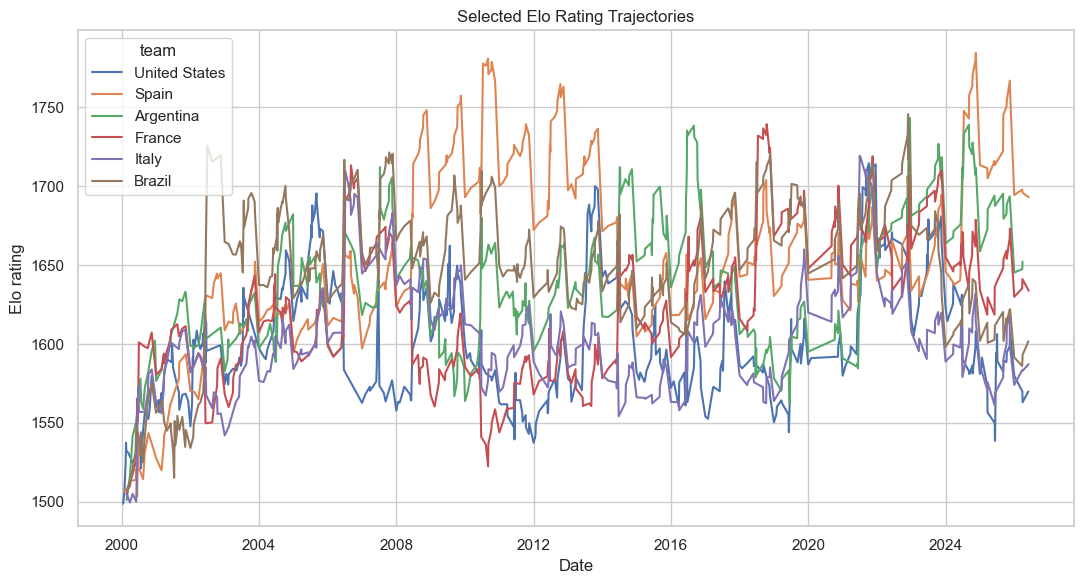

In [5]:
trajectory_teams = ["Argentina", "France", "Spain", "Brazil", "United States", "Italy"]
trajectory = history.loc[history["team"].isin(trajectory_teams)].copy()

fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(data=trajectory, x="date", y="rating", hue="team", ax=ax)
ax.set_title("Selected Elo Rating Trajectories")
ax.set_xlabel("Date")
ax.set_ylabel("Elo rating")
plt.tight_layout()
plt.show()

## Leakage Check

`get_ratings_asof()` must use ratings strictly before the requested date. This is the backtest guardrail: a 2022 snapshot cannot learn from the 2022 World Cup or anything after it.

In [6]:
cutoff = pd.Timestamp("2022-11-01")
ratings_2022 = get_ratings_asof(history, cutoff)

comparison_teams = ["Argentina", "France", "Brazil", "England", "Germany", "United States"]
comparison = pd.DataFrame(
    {
        "team": comparison_teams,
        "rating_asof_2022_11_01": [ratings_2022.get(team, elo_mod.DEFAULT_RATING) for team in comparison_teams],
        "current_rating": [ratings.get(team, elo_mod.DEFAULT_RATING) for team in comparison_teams],
    }
)
comparison["delta_current_minus_asof"] = comparison["current_rating"] - comparison["rating_asof_2022_11_01"]

history_before_cutoff = history.loc[pd.to_datetime(history["date"]) < cutoff]
assert pd.to_datetime(history_before_cutoff["date"]).max() < cutoff
assert any(abs(comparison["delta_current_minus_asof"]) > 1e-9)

comparison

,team,rating_asof_2022_11_01,current_rating,delta_current_minus_asof
0,Argentina,1684.832957,1652.136338,-32.696619
1,France,1629.689205,1633.799800,4.110595
2,Brazil,1714.918850,1601.719595,-113.199255
3,England,1609.472706,1646.092588,36.619882
4,Germany,1626.621521,1615.955574,-10.665947
5,United States,1662.256043,1569.930297,-92.325746


## Tuning Sensitivity

This is only a sensitivity illustration. It shows how the top-team ordering moves when `K_BASE` and `REGRESSION_STRENGTH` change; it is not a backtest or an overfit tuning step.

In [7]:
original_k = elo_mod.K_BASE
original_regression = elo_mod.REGRESSION_STRENGTH
scenarios = [
    (30.0, 0.15),
    (30.0, 0.35),
    (50.0, 0.15),
    (50.0, 0.35),
]

scenario_rows = []
try:
    for k_base, regression in scenarios:
        elo_mod.K_BASE = k_base
        elo_mod.REGRESSION_STRENGTH = regression
        scenario_ratings, _ = elo_mod.compute_elo_ratings(results)
        top = sorted(scenario_ratings.items(), key=lambda item: item[1], reverse=True)[:10]
        for rank, (team, rating) in enumerate(top, start=1):
            scenario_rows.append(
                {
                    "scenario": f"K={k_base:.0f}, regression={regression:.2f}",
                    "rank": rank,
                    "team": team,
                    "rating": rating,
                }
            )
finally:
    elo_mod.K_BASE = original_k
    elo_mod.REGRESSION_STRENGTH = original_regression

sensitivity = pd.DataFrame(scenario_rows)
sensitivity.pivot(index="rank", columns="scenario", values="team")

scenario,"K=30, regression=0.15","K=30, regression=0.35","K=50, regression=0.15","K=50, regression=0.35"
rank,,,,
1,Spain,Morocco,Spain,Morocco
2,Morocco,Spain,Morocco,Nigeria
3,Argentina,Senegal,Argentina,Spain
4,Senegal,Nigeria,Senegal,Senegal
5,England,Algeria,England,Algeria
6,Japan,Mexico,Nigeria,Mexico
7,France,Argentina,Mexico,Egypt
8,Mexico,Egypt,Japan,Ivory Coast
9,Portugal,England,France,Argentina


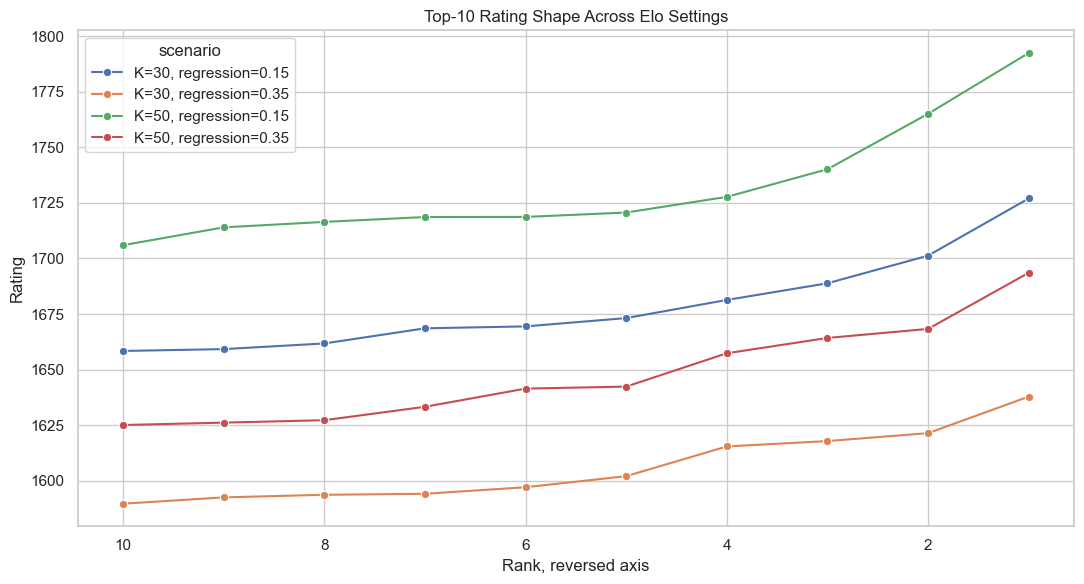

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.lineplot(data=sensitivity, x="rank", y="rating", hue="scenario", marker="o", ax=ax)
ax.invert_xaxis()
ax.set_title("Top-10 Rating Shape Across Elo Settings")
ax.set_xlabel("Rank, reversed axis")
ax.set_ylabel("Rating")
plt.tight_layout()
plt.show()

In [16]:
import inspect
from src.poisson_model import team_lambdas
print(inspect.signature(team_lambdas))

(rating_a: 'float', rating_b: 'float', team_a: 'str | None' = None, team_b: 'str | None' = None, neutral: 'bool' = True) -> 'tuple[float, float]'


In [17]:
print(repr(config.SPREAD), repr(config.BASE_GOALS))
ra, rb = 1933, 1300
print("gap:", ra - rb, "arg:", config.SPREAD * (ra - rb))

0.0018 1.35
gap: 633 arg: 1.1394


In [18]:
import config
from src.poisson_model import team_lambdas
print("SPREAD in config:", config.SPREAD)
print("exp arg for 633 gap:", config.SPREAD * 633)   # should be ~1.1, NOT ~600
print(team_lambdas(1933, 1300, neutral=True))         # the call that overflowed

SPREAD in config: 0.0018
exp arg for 633 gap: 1.1394
(4.218605370278284, 0.4320148105912493)


In [19]:
import numpy as np
from src.poisson_model import team_lambdas, score_matrix, outcome_probs
from src.optimizer import best_score, most_likely_outcome

# (rating_a, rating_b, label) — a blowout, a mismatch, and an even game
tests = [
    (1933, 1300, "Spain vs minnow (huge favorite)"),
    (1933, 1786, "Spain vs Netherlands (favorite)"),
    (1820, 1817, "Brazil vs Japan (coin flip)"),
]
for ra, rb, label in tests:
    la, lb = team_lambdas(ra, rb, neutral=True)
    m = score_matrix(la, lb)
    ph, pd, pa = outcome_probs(m)
    print(f"{label}")
    print(f"   lambdas: {la:.2f} - {lb:.2f}   EV-score: {best_score(m)}   "
          f"P(W/D/L): {ph:.0%}/{pd:.0%}/{pa:.0%}")

Spain vs minnow (huge favorite)
   lambdas: 4.22 - 0.43   EV-score: (4, 0)   P(W/D/L): 95%/4%/1%
Spain vs Netherlands (favorite)
   lambdas: 1.76 - 1.04   EV-score: (1, 1)   P(W/D/L): 54%/23%/22%
Brazil vs Japan (coin flip)
   lambdas: 1.36 - 1.34   EV-score: (1, 1)   P(W/D/L): 37%/26%/37%


In [20]:
import config; config.SPREAD = 0.0024
import importlib, src.poisson_model, src.optimizer
importlib.reload(src.poisson_model); importlib.reload(src.optimizer)
from src.poisson_model import team_lambdas, score_matrix, outcome_probs
from src.optimizer import best_score
for ra, rb, label in [(1933,1300,"minnow"),(1933,1786,"Netherlands"),(1820,1817,"coin flip")]:
    la,lb=team_lambdas(ra,rb,neutral=True); m=score_matrix(la,lb); ph,pd,pa=outcome_probs(m)
    print(f"{label}: λ {la:.2f}-{lb:.2f}  EV {best_score(m)}  W/D/L {ph:.0%}/{pd:.0%}/{pa:.0%}")

minnow: λ 5.00-0.30  EV (5, 0)  W/D/L 98%/2%/0%
Netherlands: λ 1.92-0.95  EV (2, 1)  W/D/L 60%/22%/18%
coin flip: λ 1.36-1.34  EV (1, 1)  W/D/L 38%/26%/37%
